In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=cancer.feature_names)
df['diagnosis'] = cancer.target_names[y]

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Baseline SVM
svm = SVC()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))


Baseline Accuracy: 0.935672514619883


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

pipe.fit(X_train, y_train)
print("Scaled Accuracy:", accuracy_score(y_test, pipe.predict(X_test)))


Scaled Accuracy: 0.9766081871345029


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.001],
    "svm__kernel": ["rbf", "linear"]
}

grid = GridSearchCV(pipe, param_grid=params, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_
print("Tuned Test Accuracy:", accuracy_score(y_test, best_model.predict(X_test)))


Best Parameters: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV Score: 0.9698101265822784
Tuned Test Accuracy: 0.9883040935672515


In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=cancer.feature_names)
df['diagnosis'] = cancer.target_names[y]

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

print("Logistic Regression Accuracy:", lr_acc)


Logistic Regression Accuracy: 0.9824561403508771


In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))

print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.9766081871345029


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))

print("kNN Accuracy:", knn_acc)


kNN Accuracy: 0.9590643274853801


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.9707602339181286


In [ ]:
print("Accuracy Comparison:")
print("Logistic Regression:", lr_acc)
print("SVM:", svm_acc)
print("kNN:", knn_acc)
print("Random Forest:", rf_acc)


Accuracy Comparison:
Logistic Regression: 0.9824561403508771
SVM: 0.9766081871345029
kNN: 0.9590643274853801
Random Forest: 0.9707602339181286


In [ ]:
print("SVM improvement over Logistic:", svm_acc - lr_acc)
print("RF improvement over kNN:", rf_acc - knn_acc)


SVM improvement over Logistic: -0.005847953216374213
RF improvement over kNN: 0.011695906432748537


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Logistic": LogisticRegression(max_iter=5000),
    "SVM": SVC(),
    "kNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name, "Mean Accuracy:", np.mean(scores))


Logistic Mean Accuracy: 0.9507995652848935
SVM Mean Accuracy: 0.9121720229777983
kNN Mean Accuracy: 0.9279459711224964
RandomForest Mean Accuracy: 0.968390001552554


                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.980686   0.978224  0.991588  0.984767
SVM                  0.973638   0.975367  0.983138  0.979113
kNN                  0.964850   0.962264  0.983099  0.972304
Random Forest        0.956094   0.959039  0.971909  0.965198


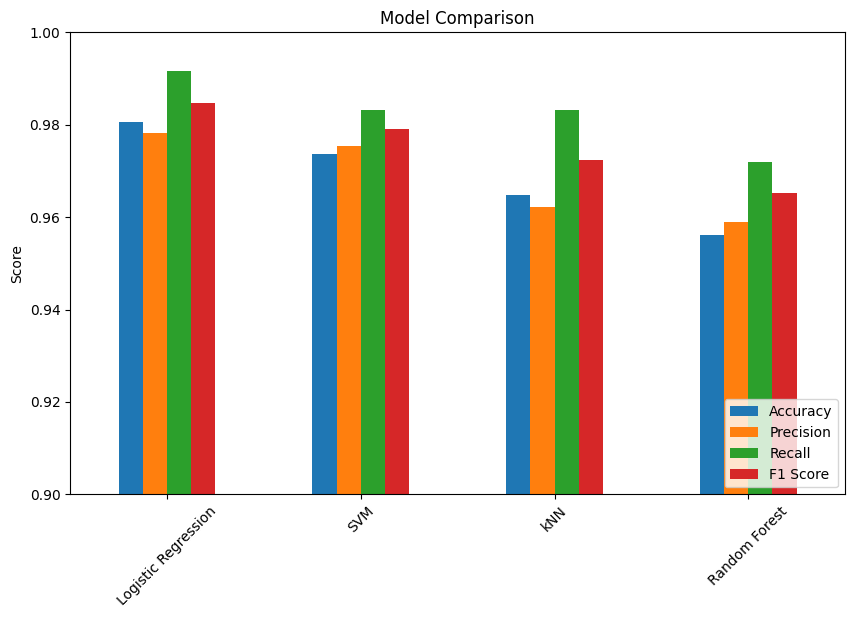

Best Model Based on Accuracy: Logistic Regression
Best Parameters: {'model__C': 10, 'model__gamma': 0.01}
Best Score: 0.9789318428815401


In [ ]:

# ✅ Step 1: Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# ---

# ✅ Step 2: Define Models

# We standardize when needed using a Pipeline.

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ]),

    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Random Forest": RandomForestClassifier(random_state=42)
}

# ---

# ✅ Step 3: Cross-Validation Comparison

# We evaluate multiple metrics:

# * Accuracy
# * Precision
# * Recall
# * F1-score

results = {}

for name, model in models.items():
    scores = cross_validate(
        model, X, y,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1"]
    )

    results[name] = {
        "Accuracy": np.mean(scores["test_accuracy"]),
        "Precision": np.mean(scores["test_precision"]),
        "Recall": np.mean(scores["test_recall"]),
        "F1 Score": np.mean(scores["test_f1"])
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)


# 📈 Step 4: Plot Comparison Graph

results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0)
plt.legend(loc="lower right")
plt.show()


# 🏆 Step 5: Automatically Select Best Model

best_model = results_df["Accuracy"].idxmax()
print("Best Model Based on Accuracy:", best_model)



# You can automatically tune hyperparameters using:

from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01]
}

grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", SVC())]),
    param_grid,
    cv=5
)

grid.fit(X, y)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

# ---

# 🎯 Final Takeaway

# To measure change in accuracy when changing algorithms:

# 1. Fix dataset
# 2. Fix preprocessing
# 3. Use cross-validation
# 4. Compare multiple metrics
# 5. Visualize results
# 6. Select best model programmatically

